In [1]:
import pandas as pd
import numpy as np
import os
import sys
import json
from scipy.stats import chi2_contingency, mannwhitneyu, normaltest
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, average_precision_score, log_loss, precision_recall_curve, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.extract_data import extract_data
from src.optuna_tun import optimize_hyperparameters, get_base_train_params, load_config

c:\Users\artur\Documents\porto-seguro-driver-pred\porto-seg-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
select_query = f"""
        SELECT
            *
        FROM raw.train
    """

df_train_original = extract_data(select_query)

In [3]:
y = df_train_original['target']
X = df_train_original[[col for col in df_train_original.columns if col not in ['target', 'id']]]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=df_train_original['target']
    )

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [15]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
ps_ind_01,476169.0,1.900061,1.983412,0.000000,0.000000,1.000000,3.000000,7.000000
ps_ind_02_cat,476169.0,1.358866,0.664223,-1.000000,1.000000,1.000000,2.000000,4.000000
ps_ind_03,476169.0,4.422892,2.699456,0.000000,2.000000,4.000000,6.000000,11.000000
ps_ind_04_cat,476169.0,0.416791,0.493292,-1.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_05_cat,476169.0,0.405157,1.350204,-1.000000,0.000000,0.000000,0.000000,6.000000
ps_ind_06_bin,476169.0,0.393047,0.488428,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_07_bin,476169.0,0.257079,0.437024,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_08_bin,476169.0,0.163996,0.370273,0.000000,0.000000,0.000000,0.000000,1.000000
ps_ind_09_bin,476169.0,0.185877,0.389008,0.000000,0.000000,0.000000,0.000000,1.000000
ps_ind_10_bin,476169.0,0.000378,0.019439,0.000000,0.000000,0.000000,0.000000,1.000000


In [16]:
df_train['target'].value_counts(normalize=True)

target
0    0.963553
1    0.036447
Name: proportion, dtype: float64

In [4]:
cat_features = [col for col in df_train.columns if col.endswith('_cat')]
bin_features = [col for col in df_train.columns if col.endswith('_bin')]

def column_type_converter(df):

    for col in df.columns:
        if col in cat_features or col in bin_features:
            df[col] = df[col].astype('string')
    
    return df

def categorical_and_bin_analysis(df, target_col = 'target', significance_level=0.05):

    df_cat = df[cat_features + bin_features + [target_col]]

    cat_bin_columns = [col for col in df_cat.columns if col != target_col]

    distinct_class = [len(df_cat[col].unique()) for col in df_cat.columns if col != target_col]

    null_perc = [100*len(df_cat[col].values[df_cat[col]=='-1'])/len(df_cat[col].values) for col in df_cat.columns if col != target_col]

    suff_cat_chi2 = ['Yes' if pd.crosstab(df[col], df[target_col]).size >= 2 else 'No' for col in df_cat.columns if col != target_col]

    suff_exp_chi2 = ['Yes' if np.all(pd.crosstab(df[col], df[target_col]) >= 5) else 'No' for col in df_cat.columns if col != target_col]

    p_value_chi2 = [round(chi2_contingency(pd.crosstab(df[col], df[target_col]))[1],3) if pd.crosstab(df[col], df[target_col]).size >= 2 and np.all(pd.crosstab(df[col], df[target_col]) >= 5)
                    else np.nan for col in df_cat.columns if col != target_col]
    
    significant_association = ['Yes' if p < significance_level else 'No' for p in p_value_chi2]
    
    return pd.DataFrame({
        "Columns": cat_bin_columns,
        "Distinct_Classes": distinct_class,
        "Nulls %": null_perc,
        "Sufficient Categories for Chi2": suff_cat_chi2,
        "Sufficient Expected Freq for Chi2": suff_exp_chi2,
        "P-Values Association With Target": p_value_chi2,
        "Significant Association With Target": significant_association
    })


def numerical_analysis(df, target_col = 'target', significance_level=0.05):

    df_num = df[[col for col in df.columns if col not in cat_features + bin_features + ['id']]]

    num_columns = [col for col in df_num.columns if col != target_col]

    null_perc = [100*len(df_num[col].values[df_num[col]==-1])/len(df_num[col].values) for col in df_num.columns if col != target_col]

    mean_values = [np.mean(df_num[col].values[df_num[col] != -1]) for col in df_num.columns if col != target_col]

    std_values = [np.std(df_num[col].values[df_num[col] != -1], ddof=1) for col in df_num.columns if col != target_col]

    cv_values = [s/m for m, s in zip(mean_values, std_values)]

    median_values = [np.median(df_num[col].values[df_num[col] != -1]) for col in df_num.columns if col != target_col]

    normal_dist = ['Yes' if normaltest(df_num[col].values[df_num[col] != -1])[1] >= significance_level else 'No' for col in df_num.columns if col != target_col]
    
    significant_diff = ['Yes' if mannwhitneyu(df[(df[target_col] == 0) & (df[col] != -1)][col], df[(df[target_col] == 1) & (df[col] != -1)][col])[1] < significance_level
                               else 'No' for col in df_num.columns if col != target_col]
    
    means_diff = [np.mean(df[(df[target_col] == 1) & (df[col] != -1)][col]) - np.mean(df[(df[target_col] == 0) & (df[col] != -1)][col]) for col in df_num.columns if col != target_col]

    median_diff = [np.median(df[(df[target_col] == 1) & (df[col] != -1)][col]) - np.median(df[(df[target_col] == 0) & (df[col] != -1)][col]) for col in df_num.columns if col != target_col]
    
    return pd.DataFrame({
        "Columns": num_columns,
        "Nulls %": null_perc,
        "Mean": mean_values,
        "Std. Dev.": std_values,
        "Coeff. of Variation": cv_values,
        "Median": median_values,
        "Normal Dist.": normal_dist,
        "Sign. Diff Target": significant_diff,
        "Means Diff. Target": means_diff,
        "Medians Diff. Target": median_diff
    })

In [5]:
df_train_new = column_type_converter(df_train)

In [6]:
cat_study_df = categorical_and_bin_analysis(df_train_new)
num_study_df = numerical_analysis(df_train_new)

In [7]:
cat_study_df

,Columns,Distinct_Classes,Nulls %,Sufficient Categories for Chi2,Sufficient Expected Freq for Chi2,P-Values Association With Target,Significant Association With Target
0,ps_ind_02_cat,5,0.034652,Yes,Yes,0.000,Yes
1,ps_ind_04_cat,3,0.013021,Yes,Yes,0.000,Yes
2,ps_ind_05_cat,8,0.967514,Yes,Yes,0.000,Yes
3,ps_car_01_cat,13,0.017641,Yes,Yes,0.000,Yes
4,ps_car_02_cat,3,0.000840,Yes,No,NaN,No
5,ps_car_03_cat,3,69.109917,Yes,Yes,0.000,Yes
6,ps_car_04_cat,10,0.000000,Yes,No,NaN,No
7,ps_car_05_cat,3,44.758059,Yes,Yes,0.000,Yes
8,ps_car_06_cat,18,0.000000,Yes,Yes,0.000,Yes
9,ps_car_07_cat,3,1.923897,Yes,Yes,0.000,Yes


In [8]:
num_study_df

,Columns,Nulls %,Mean,Std. Dev.,Coeff. of Variation,Median,Normal Dist.,Sign. Diff Target,Means Diff. Target,Medians Diff. Target
0,ps_ind_01,0.000000,1.900061,1.983412,1.043868,1.000000,No,Yes,0.194795,0.000000
1,ps_ind_03,0.000000,4.422892,2.699456,0.610337,4.000000,No,Yes,0.116772,0.000000
2,ps_ind_14,0.000000,0.012424,0.127234,10.240891,0.000000,No,Yes,0.004986,0.000000
3,ps_ind_15,0.000000,7.301170,3.545083,0.485550,7.000000,No,Yes,-0.400648,0.000000
4,ps_reg_01,0.000000,0.610903,0.287699,0.470940,0.700000,No,Yes,0.035980,0.000000
5,ps_reg_02,0.000000,0.439614,0.404638,0.920440,0.300000,No,Yes,0.076819,0.100000
6,ps_reg_03,18.117307,0.894317,0.345343,0.386153,0.801951,No,Yes,0.062248,0.066416
7,ps_car_11,0.001050,2.345058,0.833024,0.355226,3.000000,No,No,-0.010434,0.000000
8,ps_car_12,0.000000,0.379918,0.058269,0.153373,0.374166,No,Yes,0.012080,0.025834
9,ps_car_13,0.000000,0.813198,0.224455,0.276015,0.765811,No,Yes,0.064050,0.051985


In [9]:
cat_features_selected = [col for col in cat_study_df['Columns'].values if cat_study_df.loc[cat_study_df['Columns']==col]['Nulls %'].values[0] < 5 and 
                                                                                            cat_study_df.loc[cat_study_df['Columns']==col]['Significant Association With Target'].values[0] == 'Yes']

num_features_selected = [col for col in num_study_df['Columns'].values if num_study_df.loc[num_study_df['Columns']==col]['Nulls %'].values[0] < 5 and 
                                                                                            num_study_df.loc[num_study_df['Columns']==col]['Sign. Diff Target'].values[0] == 'Yes']

selected_features = cat_features_selected + num_features_selected

selected_features

['ps_ind_02_cat',
 'ps_ind_04_cat',
 'ps_ind_05_cat',
 'ps_car_01_cat',
 'ps_car_06_cat',
 'ps_car_07_cat',
 'ps_car_08_cat',
 'ps_car_09_cat',
 'ps_car_11_cat',
 'ps_ind_06_bin',
 'ps_ind_07_bin',
 'ps_ind_08_bin',
 'ps_ind_09_bin',
 'ps_ind_12_bin',
 'ps_ind_16_bin',
 'ps_ind_17_bin',
 'ps_ind_18_bin',
 'ps_ind_01',
 'ps_ind_03',
 'ps_ind_14',
 'ps_ind_15',
 'ps_reg_01',
 'ps_reg_02',
 'ps_car_12',
 'ps_car_13',
 'ps_car_15']

In [132]:
X = df_train_new[selected_features]
y = df_train_new['target']

ratio = float(y.value_counts()[0] / y.value_counts()[1])

features_tested = []
mean_prc_auc = []

In [133]:
for drop_col in selected_features:

    kfold = StratifiedKFold(n_splits=3)

    columns_trans = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), [c for c in cat_features_selected if (len(df_train_new[c].unique()) < 10) and (c != drop_col)]),
            ('target_encoder', TargetEncoder(smoothing=10), [c for c in cat_features_selected if (len(df_train_new[c].unique()) >= 10) and (c != drop_col)])
        ],
        remainder='passthrough'
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', columns_trans),
        ('classifier', XGBClassifier(scale_pos_weight=ratio, random_state=42))
    ])
    
    X_selected = X.drop(drop_col, axis=1)

    cv_results = cross_val_score(pipeline, X_selected, y, cv=kfold, scoring='average_precision')

    features_tested.append(drop_col)

    mean_prc_auc.append(np.mean(np.array(cv_results)))

features_results = pd.DataFrame({"Feature": features_tested,
                                 "Mean Model Score": mean_prc_auc}).sort_values(by='Mean Model Score')

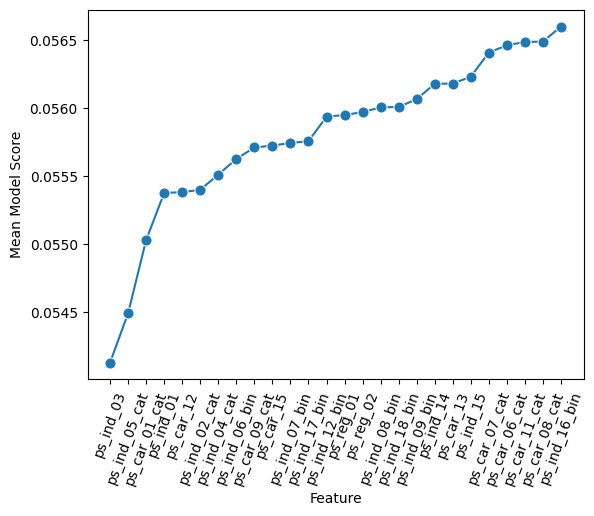

In [134]:
sns.lineplot(x="Feature", y="Mean Model Score", data=features_results, marker='o', markersize=8)
plt.xticks(rotation=70)
plt.show()

In [135]:
x_input = df_train_new[selected_features]
y_output = df_train_new['target']

ratio = float(y_output.value_counts()[0]) / y_output.value_counts()[1]

k = 3
kf = StratifiedKFold(n_splits=k)

models = {
    "RandomForestClassifier": RandomForestClassifier(class_weight='balanced', random_state=42), #class_weight as balanced due to extremely imbalanced classes (1 and 0)
    "LightGBMClassifier": LGBMClassifier(verbose=-1, scale_pos_weight=ratio, random_state=42), #giving more weight to positive instances due to imbalance
    "XGBoostClassifier": XGBClassifier(scale_pos_weight=ratio, random_state=42), #giving more weight to positive instances due to imbalance
}

model_metrics = {}

for model_name, model in models.items():
    fold_metrics = {
        "F1-Score": [],
        "Precision": [],
        "Recall": [],
        "ROC_AUC": [],
        "Precision_Recall_AUC": [],
        "Log-Loss": [],
        "Training_Time": [],
        "Inference_Time": []
    }

    for train_index, val_index in kf.split(x_input, y=y_output):
        X_train_fold, X_val_fold = x_input.iloc[train_index], x_input.iloc[val_index]
        y_train_fold, y_val_fold = y_output.iloc[train_index], y_output.iloc[val_index]

        columns_trans = ColumnTransformer(
            transformers=[
                ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), [c for c in X_train_fold.columns if (len(X_train_fold[c].unique()) < 10) and (c.endswith('_cat') or c.endswith('_bin'))]),
                ('target_encoder', TargetEncoder(smoothing=10), [c for c in X_train_fold.columns if (len(X_train_fold[c].unique()) >= 10) and (c.endswith('_cat') or c.endswith('_bin'))])
            ],
            remainder='passthrough'
        ).set_output(transform="pandas")

        pipeline = Pipeline(steps=[
            ('preprocessor', columns_trans),
            ('classifier', model)
        ])

        start_time_training = time.time()
        pipeline.fit(X_train_fold, y_train_fold.values.ravel())
        training_time = time.time() - start_time_training

        start_time_inference = time.time()
        y_pred = pipeline.predict(X_val_fold)
        inference_time = (time.time() - start_time_inference) / len(X_val_fold)

        y_pred_proba = pipeline.predict_proba(X_val_fold)[:, 1]

        f1 = f1_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred)
        recall = recall_score(y_val_fold, y_pred)
        roc_auc = roc_auc_score(y_val_fold, y_pred_proba)
        precision_recall_auc = average_precision_score(y_val_fold, y_pred_proba)
        log_loss_metric = log_loss(y_val_fold, y_pred_proba)

        fold_metrics["F1-Score"].append(f1)
        fold_metrics["Precision"].append(precision)
        fold_metrics["Recall"].append(recall)
        fold_metrics["ROC_AUC"].append(roc_auc)
        fold_metrics["Precision_Recall_AUC"].append(precision_recall_auc)
        fold_metrics["Log-Loss"].append(log_loss_metric)
        fold_metrics["Training_Time"].append(training_time)
        fold_metrics["Inference_Time"].append(inference_time)

    mean_metrics = {
        "F1-Score": round(np.mean(fold_metrics["F1-Score"]), 4),
        "Precision": round(np.mean(fold_metrics["Precision"]), 4),
        "Recall": round(np.mean(fold_metrics["Recall"]), 4),
        "ROC_AUC": round(np.mean(fold_metrics["ROC_AUC"]), 4),
        "Precision_Recall_AUC": round(np.mean(fold_metrics["Precision_Recall_AUC"]), 4),
        "Log-Loss": round(np.mean(fold_metrics["Log-Loss"]), 4),
        "Training_Time": round(np.mean(fold_metrics["Training_Time"]), 4),
        "Inference_Time": round(np.mean(fold_metrics["Inference_Time"]), 8)
    }

    model_metrics[model_name] = mean_metrics

In [136]:
df_model_metrics = pd.DataFrame.from_dict(model_metrics, orient='index')

In [137]:
df_model_metrics

,F1-Score,Precision,Recall,ROC_AUC,Precision_Recall_AUC,Log-Loss,Training_Time,Inference_Time
RandomForestClassifier,0.0003,0.2444,0.0002,0.5834,0.0485,0.2424,159.3619,0.000087
LightGBMClassifier,0.0982,0.0541,0.5350,0.6260,0.0615,0.6313,8.2033,0.000009
XGBoostClassifier,0.0967,0.0545,0.4307,0.6002,0.0564,0.5801,9.0907,0.000013


In [138]:
models_ranks = {"Metric": [],
                "Best Model": [],
                "Value": []}

for metric in df_model_metrics.columns:
    models_ranks["Metric"].append(metric)

    if metric in ['Log-Loss', 'Training_Time', 'Inference_Time']:
        models_ranks["Best Model"].append(df_model_metrics.loc[df_model_metrics[metric]==np.min(df_model_metrics[metric].values)].index[0])
        models_ranks["Value"].append(np.min(df_model_metrics[metric].values))
    else:
        models_ranks["Best Model"].append(df_model_metrics.loc[df_model_metrics[metric]==np.max(df_model_metrics[metric].values)].index[0])
        models_ranks["Value"].append(np.max(df_model_metrics[metric].values))

pd.DataFrame(models_ranks)

,Metric,Best Model,Value
0,F1-Score,LightGBMClassifier,0.098200
1,Precision,RandomForestClassifier,0.244400
2,Recall,LightGBMClassifier,0.535000
3,ROC_AUC,LightGBMClassifier,0.626000
4,Precision_Recall_AUC,LightGBMClassifier,0.061500
5,Log-Loss,RandomForestClassifier,0.242400
6,Training_Time,LightGBMClassifier,8.203300
7,Inference_Time,LightGBMClassifier,0.000009


In [10]:
X_train = df_train_new[selected_features]
y_train = df_train_new['target']

best_params, study = optimize_hyperparameters(X_train, y_train)

[I 2025-06-26 15:04:13,812] A new study created in memory with name: no-name-ead688f4-2d82-4183-89db-c6edc6a5b6e7
INFO:src.optuna_tun:Starting hyperparameter optimization...


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0536898	valid_0's binary_logloss: 0.177931
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0526752	valid_0's binary_logloss: 0.178181
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0528115	valid_0's binary_logloss: 0.17832


[I 2025-06-26 15:04:34,945] Trial 0 finished with value: 0.054127847290801966 and parameters: {'num_leaves': 85, 'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.07661100707771368, 'min_child_samples': 35, 'colsample_bytree': 0.40919616423534183, 'subsample': 0.6232334448672797, 'reg_alpha': 0.21423021757741043, 'reg_lambda': 0.010129197956845729, 'scale_pos_weight': 'balanced'}. Best is trial 0 with value: 0.054127847290801966.


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.053587	valid_0's binary_logloss: 0.338682
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0528608	valid_0's binary_logloss: 0.337618
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0541583	valid_0's binary_logloss: 0.337666


[I 2025-06-26 15:04:54,861] Trial 1 finished with value: 0.053781355256100394 and parameters: {'num_leaves': 150, 'n_estimators': 50, 'max_depth': 12, 'learning_rate': 0.16967533607196555, 'min_child_samples': 46, 'colsample_bytree': 0.42727747704497043, 'subsample': 0.6733618039413735, 'reg_alpha': 0.00033205591037519585, 'reg_lambda': 0.00420515645091387, 'scale_pos_weight': 'balanced'}. Best is trial 0 with value: 0.054127847290801966.


...

[I 2025-06-26 15:35:42,443] Trial 97 finished with value: 0.062404547001245765 and parameters: {'num_leaves': 120, 'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.01627482548278753, 'min_child_samples': 108, 'colsample_bytree': 0.9049778897207557, 'subsample': 0.8189153436594839, 'reg_alpha': 0.3064369162696595, 'reg_lambda': 0.00040836354711197483, 'scale_pos_weight': 'balanced'}. Best is trial 45 with value: 0.08400898215520976.


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505262	valid_0's binary_logloss: 0.156528
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0478441	valid_0's binary_logloss: 0.156555
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0485582	valid_0's binary_logloss: 0.156551


[I 2025-06-26 15:36:00,324] Trial 98 finished with value: 0.08400898215520976 and parameters: {'num_leaves': 165, 'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.010680565938943044, 'min_child_samples': 16, 'colsample_bytree': 0.9724928342328059, 'subsample': 0.9641444180230379, 'reg_alpha': 0.7584211899555307, 'reg_lambda': 0.0001004964989633309, 'scale_pos_weight': 'balanced'}. Best is trial 45 with value: 0.08400898215520976.


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0510608	valid_0's binary_logloss: 0.156585
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0504334	valid_0's binary_logloss: 0.156591
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0507888	valid_0's binary_logloss: 0.156581


[I 2025-06-26 15:36:20,277] Trial 99 finished with value: 0.060324697296227324 and parameters: {'num_leaves': 170, 'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.012512065248339423, 'min_child_samples': 51, 'colsample_bytree': 0.8657990508893332, 'subsample': 0.9763344209491244, 'reg_alpha': 0.7552137904652961, 'reg_lambda': 0.00010527295411381941, 'scale_pos_weight': 'balanced'}. Best is trial 45 with value: 0.08400898215520976.
INFO:src.optuna_tun:Optimization completed!
INFO:src.optuna_tun:Best score: 0.084009
INFO:src.optuna_tun:Best parameters: {'num_leaves': 25, 'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.027417861552106366, 'min_child_samples': 68, 'colsample_bytree': 0.9406949110158471, 'subsample': 0.8754120357605699, 'reg_alpha': 0.4146814474147226, 'reg_lambda': 4.0693452906566077e-05, 'scale_pos_weight': 'balanced'}


In [29]:
with open("eda_best_hyperparameters.json", "w") as json_file:
    json.dump(best_params, json_file)

In [79]:
def measure_final_performances(X_train, y_train, X_test, y_test, model, X_cal=None, y_cal=None, threshold=None, title=None):
    
    print("=========================")
    print(f"Experiment: {title}")
    print("=========================\n\n")
    
    # Model Fit
    model.fit(X_train, y_train)
    
    if X_cal is not None:

        y_pred_proba_before = model.predict_proba(X_test)[:, 1]
        
        model = CalibratedClassifierCV(estimator=FrozenEstimator(model), method='isotonic', ensemble=False)
        model.fit(X_cal, y_cal)

        y_pred_proba_after = model.predict_proba(X_test)[:, 1]

        # Step 6: Plot Calibration Curves before and after calibration
        plt.figure(figsize=(10, 7))

        # Calibration curve (before)
        prob_true_before, prob_pred_before = calibration_curve(y_test, y_pred_proba_before, n_bins=10, strategy='quantile')
        plt.plot(prob_pred_before, prob_true_before, marker='o', label='Before Calibration')

        # Calibration curve (after)
        prob_true_after, prob_pred_after = calibration_curve(y_test, y_pred_proba_after, n_bins=10, strategy='quantile')
        plt.plot(prob_pred_after, prob_true_after, marker='o', label='After Calibration')

        # Reference line (Perfect calibration)
        plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')

        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.title('Calibration Curves: Before and After Calibration')
        plt.legend()
        plt.grid(True)
        plt.show()


    if threshold is not None:

        precision_curve, recall_curve, thresholds = precision_recall_curve(y_cal, model.predict_proba(X_cal)[:, 1], ) 
        
        #the correct way to do this is to use a different dataset to tune the threshold. Here, for simplicity, we are using the same data as the one
        #used for calibrating the probabilities.
        
        f2_scores = (1 + 2**2) * (precision_curve * recall_curve) / ((2**2 * precision_curve) + recall_curve)
        best_threshold = thresholds[np.argmax(f2_scores)]

        print("==============================")
        print(f"Best Threshold: {best_threshold}")
        print("==============================")
    
    # Model Predict
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    if threshold is not None:
        y_pred = np.where(y_pred_proba >= best_threshold, 1, 0)
    else:
        y_pred = model.predict(X_test)

    # Metrics
    f1 = round(f1_score(y_test, y_pred), 3)
    precision = round(precision_score(y_test, y_pred), 3)
    recall = round(recall_score(y_test, y_pred), 3)
    f2 = round((1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall), 3)
    roc_auc = round(float(roc_auc_score(y_test, y_pred_proba)), 3)
    precision_recall_auc = round(float(average_precision_score(y_test, y_pred_proba)), 3)
    log_loss_metric = round(log_loss(y_test, y_pred_proba), 3)

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["Class 0", "Class 1"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)

    plt.plot(recall_curve, precision_curve, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')

    plt.show()

    return {'F1-Score': [f1],
            'Precision': [precision],
            'Recall': [recall],
            'F2-Score': [f2],
            'ROC AUC': [roc_auc],
            'Precision-Recall Curve AUC': [precision_recall_auc],
            'Log-Loss': [log_loss_metric]}


In [80]:
from sklearn.preprocessing import TargetEncoder     #from now on, we changed TargetEncoder to sklearn's version. Smoothing happens the same way
from sklearn.frozen import FrozenEstimator


df_test = column_type_converter(df_test)

X_test = df_test[selected_features]
y_test = df_test['target']

X = df_train_new[selected_features]
y = df_train_new['target']

with open("eda_best_hyperparameters.json", "r", encoding="utf-8") as file:
    best_params = json.load(file)

X_train, X_cal, y_train, y_cal = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=df_train_new['target']
    )

if best_params.get("scale_pos_weight") == "balanced":
    pos_count = sum(y_train)
    neg_count = len(y_train) - pos_count
    best_params["scale_pos_weight"] = neg_count / pos_count if pos_count > 0 else 1.0

best_params_full = {**get_base_train_params(load_config())[0], **best_params}

model = LGBMClassifier(**best_params_full)

columns_trans = ColumnTransformer(
        transformers=[
            ('onehot', 
             OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), 
             [c for c in X_train.columns if (len(X_train[c].unique()) < 10) and 
                       (c.endswith('_cat') or c.endswith('_bin'))]),
            ('target_encoder', 
             TargetEncoder(smooth="auto"), 
             [c for c in X_train.columns if (len(X_train[c].unique()) >= 10) and 
                       (c.endswith('_cat') or c.endswith('_bin'))])
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    ).set_output(transform="pandas")

pipeline = Pipeline(steps=[
    ('preprocessor', columns_trans),
    ('classifier', model)
])

Experiment: Hyperparameters, Calibration and Threshold




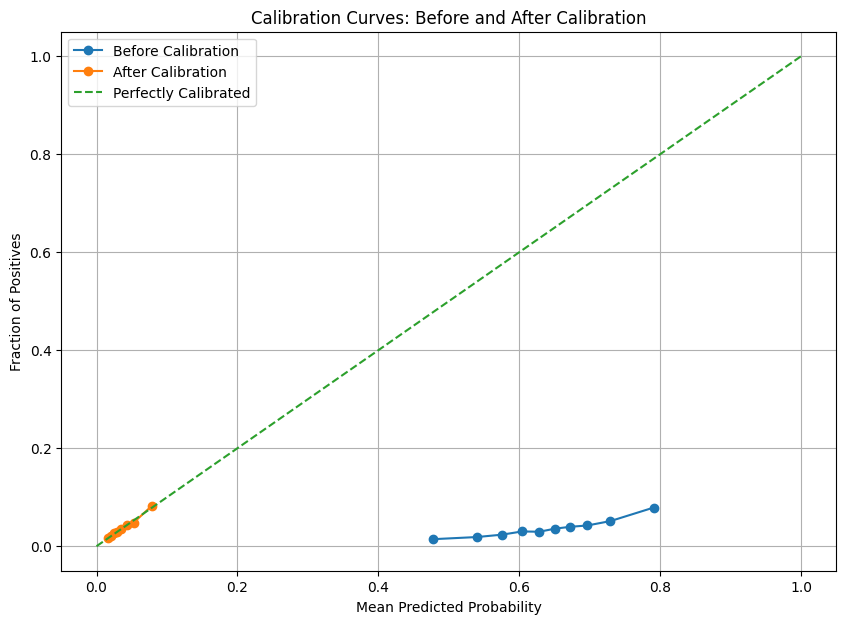

Best Threshold: 0.040865384615384616


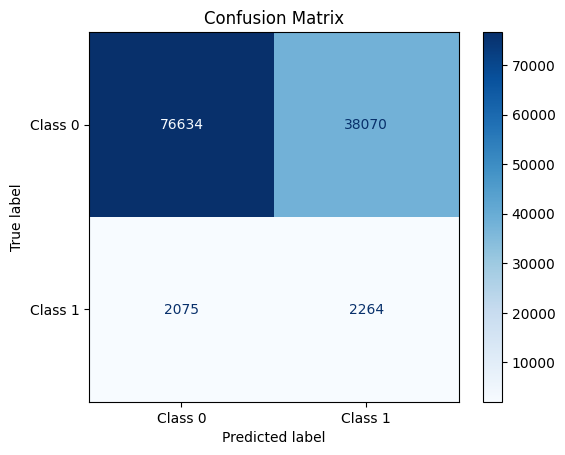

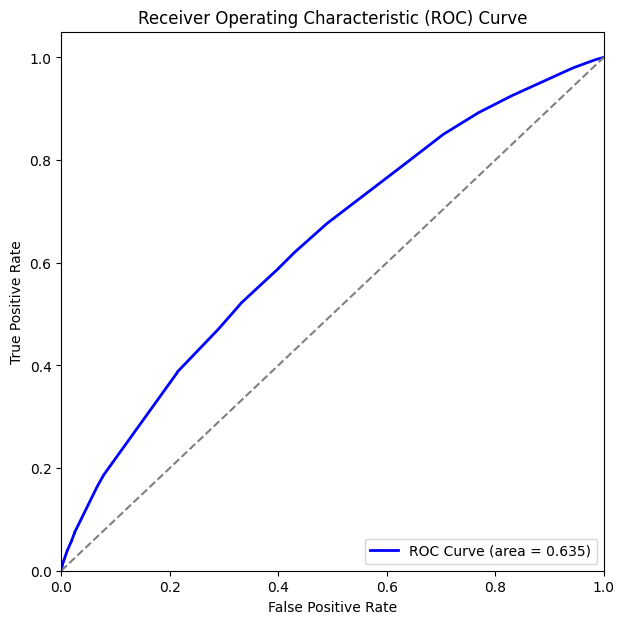

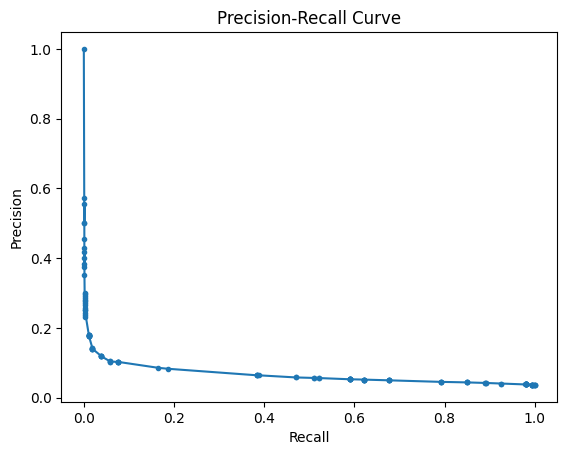

In [81]:
hyperparameters_and_calibration_and_threshold = measure_final_performances(X_train, y_train, X_test, y_test, pipeline, X_cal, y_cal, threshold='Y', title='Hyperparameters, Calibration and Threshold')

In [82]:
final_performance = pd.DataFrame(hyperparameters_and_calibration_and_threshold).T.reset_index()
final_performance.columns = ['Metric', 'Value']
final_performance

,Metric,Value
0,F1-Score,0.101
1,Precision,0.056
2,Recall,0.522
3,F2-Score,0.196
4,ROC AUC,0.635
5,Precision-Recall Curve AUC,0.061
6,Log-Loss,0.154
